In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.svm import SVC
from sklearn.inspection import DecisionBoundaryDisplay


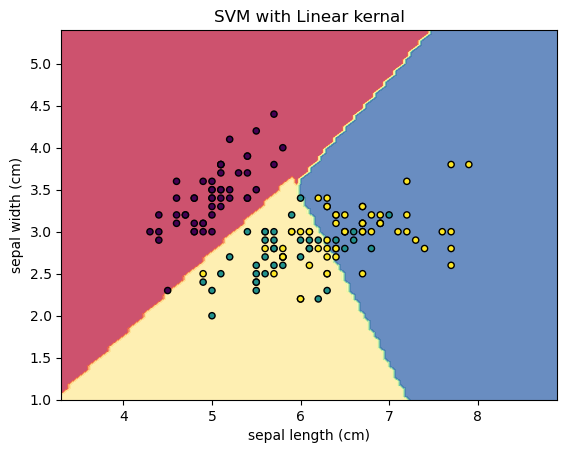

In [9]:
#1
iris = load_iris()
X = iris.data[:,:2]
Y = iris.target
svm = SVC(kernel = "linear",C=1.0)
svm.fit(X,Y)
DecisionBoundaryDisplay.from_estimator(svm,X,response_method="predict",
                                       cmap=plt.cm.Spectral,alpha=0.8,
                                       xlabel=iris.feature_names[0],
                                       ylabel=iris.feature_names[1])
plt.scatter(X[:,0],X[:,1],c=Y,s=20,edgecolors="k")
plt.title("SVM with Linear kernal")
plt.show()

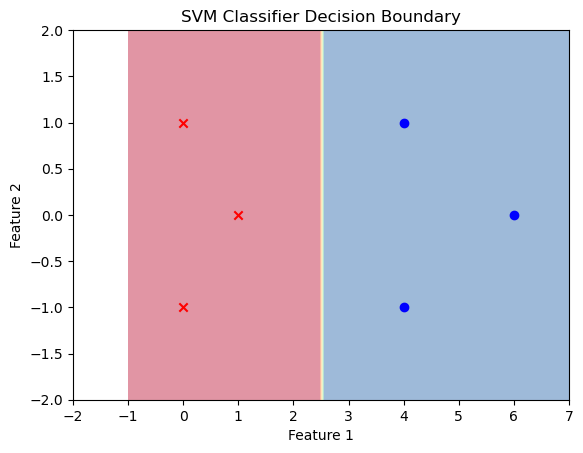

In [10]:
#2
pos_labeled = np.array([[4, 1], [4, -1], [6, 0]])
neg_labeled = np.array([[1, 0], [0, 1], [0, -1]])
X = np.vstack((pos_labeled,neg_labeled))
y = np.array([1,1,1,-1,-1,-1])
svm = SVC(kernel='linear',C=1.0)
svm.fit(X,y)
DecisionBoundaryDisplay.from_estimator(svm,X,response_method="predict",
                                       cmap=plt.cm.Spectral,alpha=0.5,
                                       xlabel='Feature 1',
                                       ylabel= 'Feature 2')
plt.scatter(X[:3, 0], X[:3, 1], c='blue', label='Positive', marker='o')
plt.scatter(X[3:, 0], X[3:, 1], c='red', label='Negative', marker='x')
plt.title('SVM Classifier Decision Boundary')
plt.xlim(-2, 7)
plt.ylim(-2, 2)
plt.show()

Predictions: [1. 1. 1. 1. 1. 1.]


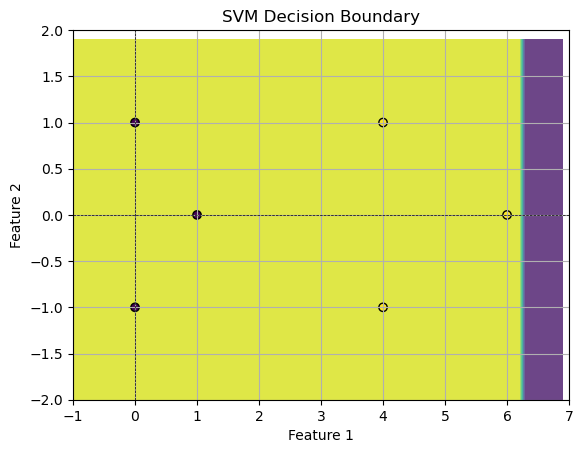

In [14]:
#3
class SimpleSVM:
    def __init__(self, learning_rate=0.01, lambda_param=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.lambda_param = lambda_param
        self.n_iterations = n_iterations
        self.w = None
        self.b = None
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0
        for _ in range(self.n_iterations):
            for idx, x_i in enumerate(X):
                if y[idx] * (np.dot(x_i, self.w) + self.b) < 1:
                    self.w -= self.learning_rate * (self.lambda_param * self.w - np.dot(x_i, y[idx]))
                    self.b -= self.learning_rate * y[idx]
                else:
                    self.w -= self.learning_rate * self.lambda_param * self.w
    def predict(self, X):
        linear_output = np.dot(X, self.w) + self.b
        return np.sign(linear_output)
    
svm = SimpleSVM(learning_rate=0.01, lambda_param=0.01, n_iterations=1000)
svm.fit(X, y)
predictions = svm.predict(X)
print("Predictions:", predictions)

def plot_decision_boundary(svm, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
    Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')
    plt.title("SVM Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.axhline(0, color='black', lw=0.5, ls='--')
    plt.axvline(0, color='black', lw=0.5, ls='--')
    plt.grid()
    plt.show()

plot_decision_boundary(svm, X, y)
            

/tmp/ipykernel_5867/3343779084.py:9: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(X1, X2, hyperplane, levels=[0], colors='red', linewidths=2, linestyles='solid', label='Hyperplane: 1 + 2X1 + 3X2 = 0')


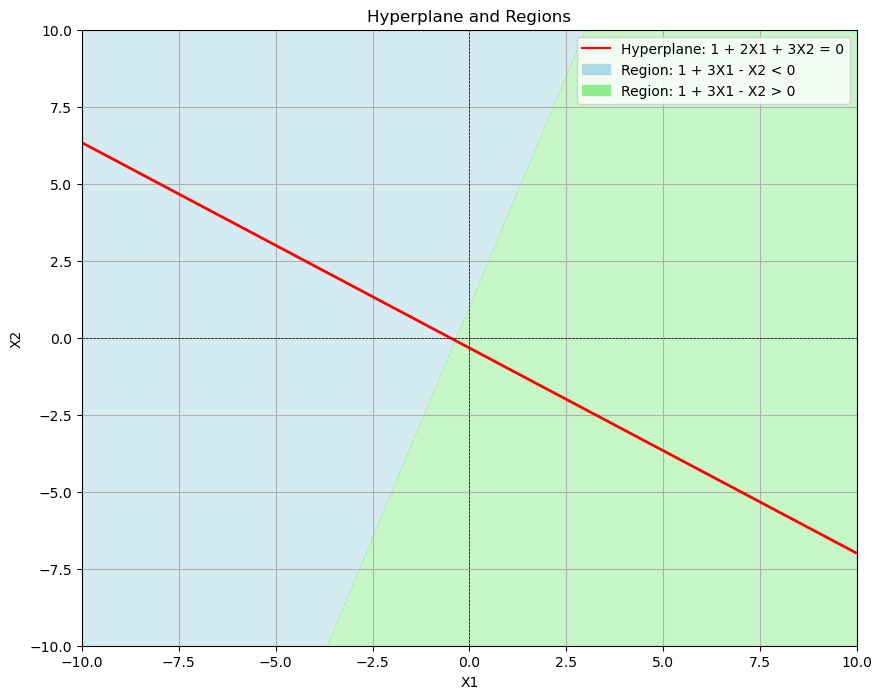

Slope of the hyperplane: -0.6666666666666666
Y-intercept of the hyperplane: -0.3333333333333333


In [17]:
#4
def plot_hyperplane_and_regions():
    x1_range = np.arange(-10, 11, 1)
    x2_range = np.arange(-10, 11, 1)
    X1, X2 = np.meshgrid(x1_range, x2_range)
    hyperplane = 1 + 2 * X1 + 3 * X2
    region = 1 + 3 * X1 - X2
    plt.figure(figsize=(10, 8))
    plt.contour(X1, X2, hyperplane, levels=[0], colors='red', linewidths=2, linestyles='solid', label='Hyperplane: 1 + 2X1 + 3X2 = 0')
    plt.contourf(X1, X2, region, levels=[-50, 0], colors='lightblue', alpha=0.5)
    plt.contourf(X1, X2, region, levels=[0, 50], colors='lightgreen', alpha=0.5)
    plt.title("Hyperplane and Regions")
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.plot([], [], color='red', label='Hyperplane: 1 + 2X1 + 3X2 = 0')
    plt.fill_between([], [], color='lightblue', label='Region: 1 + 3X1 - X2 < 0')
    plt.fill_between([], [], color='lightgreen', label='Region: 1 + 3X1 - X2 > 0')
    plt.legend()
    plt.axhline(0, color='black', lw=0.5, ls='--')
    plt.axvline(0, color='black', lw=0.5, ls='--')
    plt.xlim(-10, 10)
    plt.ylim(-10, 10)
    plt.grid()
    plt.show()
    
plot_hyperplane_and_regions()
slope = -2 / 3
intercept = -1 / 3

print(f"Slope of the hyperplane: {slope}")
print(f"Y-intercept of the hyperplane: {intercept}")

/tmp/ipykernel_5867/1475756825.py:12: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(X1, X2, region1, levels=[0], colors='blue', linewidths=2, label='Hyperplane 1: 5 + 2X1 + 5X2 = 0')
/tmp/ipykernel_5867/1475756825.py:16: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(X1, X2, region2, levels=[0], colors='red', linewidths=2, label='Hyperplane 2: 5 + 20X1 + 50X2 = 0')


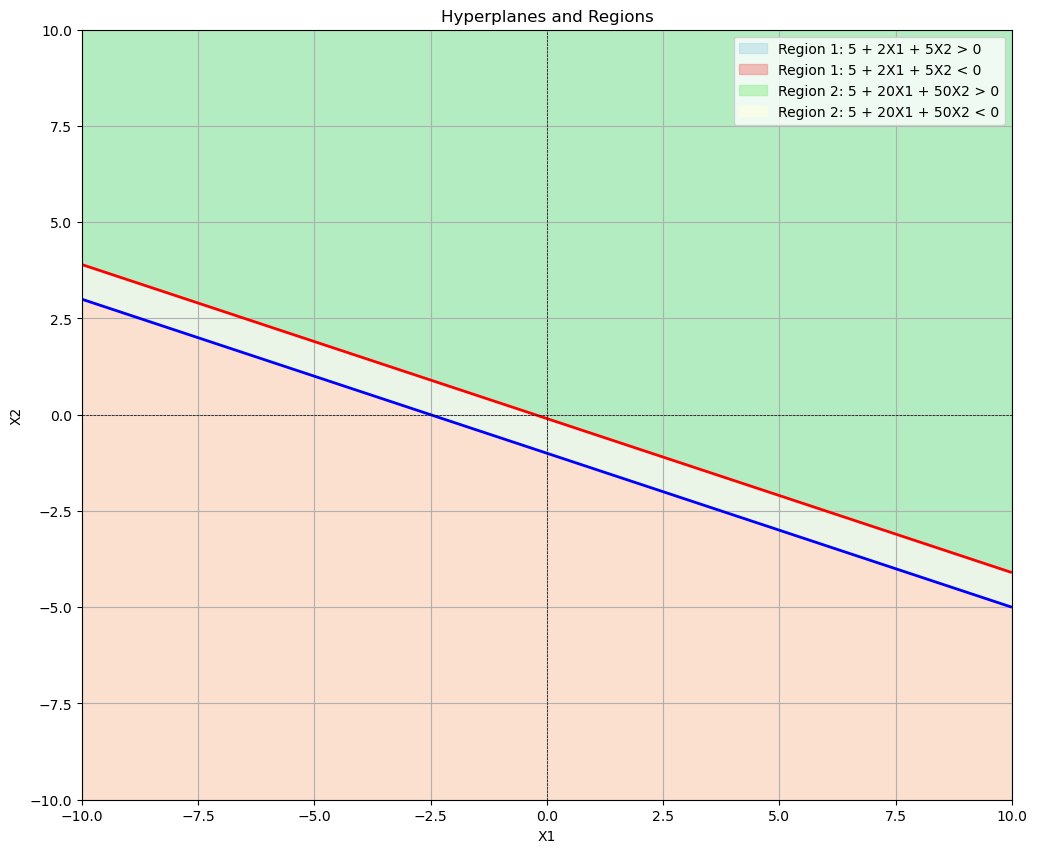

Slope of Hyperplane 1: -0.4, Intercept: -1
Slope of Hyperplane 2: -0.2, Intercept: -0.1


In [19]:
#5
def plot_hyperplanes_and_regions():
    x1_range = np.arange(-10, 11, 1)
    x2_range = np.arange(-10, 11, 1)
    X1, X2 = np.meshgrid(x1_range, x2_range)
    hyperplane1 = 5 + 2 * X1 + 5 * X2
    hyperplane2 = 5 + 20 * X1 + 50 * X2
    region1 = hyperplane1
    region2 = hyperplane2
    plt.figure(figsize=(12, 10))
    
    plt.contour(X1, X2, region1, levels=[0], colors='blue', linewidths=2, label='Hyperplane 1: 5 + 2X1 + 5X2 = 0')
    plt.fill_between(x1_range, (-5 - 2*x1_range)/5, 10, color='lightblue', alpha=0.5, label='Region 1: 5 + 2X1 + 5X2 > 0')
    plt.fill_between(x1_range, (-5 - 2*x1_range)/5, -10, color='lightcoral', alpha=0.5, label='Region 1: 5 + 2X1 + 5X2 < 0')
    
    plt.contour(X1, X2, region2, levels=[0], colors='red', linewidths=2, label='Hyperplane 2: 5 + 20X1 + 50X2 = 0')
    plt.fill_between(x1_range, (-5 - 20*x1_range)/50, 10, color='lightgreen', alpha=0.5, label='Region 2: 5 + 20X1 + 50X2 > 0')
    plt.fill_between(x1_range, (-5 - 20*x1_range)/50, -10, color='lightyellow', alpha=0.5, label='Region 2: 5 + 20X1 + 50X2 < 0')
    
    plt.title("Hyperplanes and Regions")
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.axhline(0, color='black', lw=0.5, ls='--')
    plt.axvline(0, color='black', lw=0.5, ls='--')
    plt.xlim(-10, 10)
    plt.ylim(-10, 10)
    plt.grid()
    plt.legend()
    plt.show()

plot_hyperplanes_and_regions()
slope1 = -2 / 5
intercept1 = -1
slope2 = -2 / 10
intercept2 = -1 / 10
print(f"Slope of Hyperplane 1: {slope1}, Intercept: {intercept1}")
print(f"Slope of Hyperplane 2: {slope2}, Intercept: {intercept2}")
    